# Checking different parameters for bitcoin

In [1]:
import torch
import numpy as np
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
import pandas as pd

# Load BTC CSV
btc_df = pd.read_csv(r'feature_datasets\BTC_features.csv', parse_dates=True, index_col=0)

# Define X and y
btc_y = btc_df['Close'].shift(-1)          # next-day close price
btc_X = btc_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
btc_X = btc_X.iloc[:-1]
btc_y = btc_y.iloc[:-1]

# check shapes
print("BTC X shape:", btc_X.shape)
print("BTC y shape:", btc_y.shape)

BTC X shape: (915, 29)
BTC y shape: (915,)


In [3]:
# 70% train / 30% test split (time-based)
split_idx = int(len(btc_X) * 0.7)

btc_X_train = btc_X.iloc[:split_idx].values
btc_X_test  = btc_X.iloc[split_idx:].values

btc_y_train = btc_y.iloc[:split_idx].values
btc_y_test  = btc_y.iloc[split_idx:].values

# Optional: check shapes
print("BTC X_train shape:", btc_X_train.shape)
print("BTC X_test shape:", btc_X_test.shape)
print("BTC y_train shape:", btc_y_train.shape)
print("BTC y_test shape:", btc_y_test.shape)

BTC X_train shape: (640, 29)
BTC X_test shape: (275, 29)
BTC y_train shape: (640,)
BTC y_test shape: (275,)


In [4]:
btc_test_dates = btc_df.index[-len(btc_X_test):]

In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
btc_X_train_scaled = scaler.fit_transform(btc_X_train)

# Transform TEST using the same scaler
btc_X_test_scaled = scaler.transform(btc_X_test)

# Check shapes
print("Scaled X_train shape:", btc_X_train_scaled.shape)
print("Scaled X_test shape:", btc_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [6]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
btc_y_train_scaled = y_scaler.fit_transform(btc_y_train.reshape(-1,1)).flatten()

# Scale test target
btc_y_test_scaled = y_scaler.transform(btc_y_test.reshape(-1,1)).flatten()

In [7]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for BTC using scaled target
btc_X_train_seq, btc_y_train_seq = create_sequences(btc_X_train_scaled, btc_y_train_scaled, time_steps=30)
btc_X_test_seq, btc_y_test_seq = create_sequences(btc_X_test_scaled, btc_y_test_scaled, time_steps=30)

# Check shapes
print("BTC X_train_seq shape:", btc_X_train_seq.shape)
print("BTC y_train_seq shape:", btc_y_train_seq.shape)
print("BTC X_test_seq shape:", btc_X_test_seq.shape)
print("BTC y_test_seq shape:", btc_y_test_seq.shape)

BTC X_train_seq shape: (610, 30, 29)
BTC y_train_seq shape: (610,)
BTC X_test_seq shape: (245, 30, 29)
BTC y_test_seq shape: (245,)


In [8]:
from BI_LSTM_New import BiLSTM, predict_model

In [9]:
# Get number of features from the sequences
input_size = btc_X_train_seq.shape[2]

## optimizer = SGD for epochs = 50

In [11]:
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader

# Fixed best parameters
hidden_size = 78
num_layers = 2
lr = 0.0007451964123638622
batch_size = 32
epochs = 50

# Model
input_size = btc_X_train_seq.shape[2]
model = BiLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=1
)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

# DataLoader
train_dataset = TensorDataset(
    torch.tensor(btc_X_train_seq, dtype=torch.float32),
    torch.tensor(btc_y_train_seq, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

# Training and recording loss
epoch_losses = []

model.train()
for epoch in range(epochs):
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs.squeeze(), yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    epoch_losses.append([epoch + 1, avg_loss])

# Save all 50 epoch losses into a dataframe
loss_df = pd.DataFrame(epoch_losses, columns=["Epoch", "Loss"])

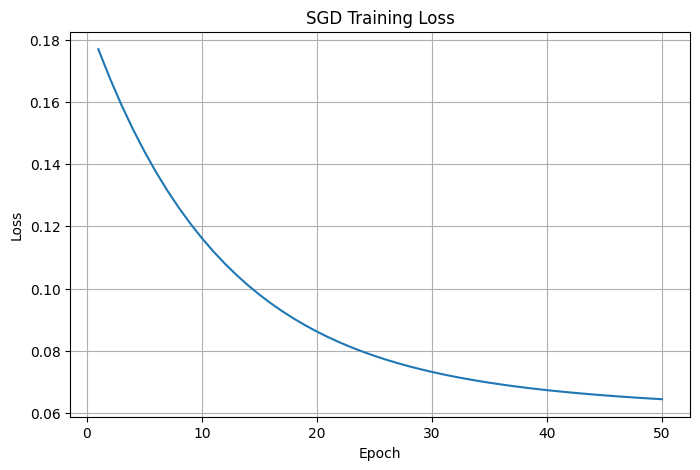

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_df["Epoch"], loss_df["Loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD Training Loss")
plt.grid(True)
plt.show()

### Testing for SGD,50

In [14]:
btc_preds = predict_model(model, btc_X_test_seq)

# Optional: check
print("Predictions shape:", btc_preds.shape)
print("First 10 predictions:", btc_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.28297406]
 [0.2819835 ]
 [0.2816921 ]
 [0.281447  ]
 [0.28147596]
 [0.2809615 ]
 [0.2810164 ]
 [0.2806043 ]
 [0.27928805]
 [0.27914703]]


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
btc_preds_actual = y_scaler.inverse_transform(btc_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
btc_y_test_actual = btc_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(btc_y_test_actual, btc_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(btc_y_test_actual, btc_preds_actual)
r2 = r2_score(btc_y_test_actual, btc_preds_actual)
mape = np.mean(np.abs((btc_y_test_actual - btc_preds_actual) / btc_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 28333706.22
RMSE: 5322.94
MAE: 4089.13
R2 Score: 0.0804
MAPE: 12.33%


In [16]:
btc_preds_actual = y_scaler.inverse_transform(btc_preds.reshape(-1,1))

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = btc_df.index[-len(btc_X_test):][30:]  # test dates aligned with sequences
actual_seq = btc_y_test[30:]                      # actual prices aligned
pred_seq = btc_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,28680.537109,30439.550781
2023-05-03,29006.308594,30388.259766
2023-05-04,28847.710938,30373.171875
2023-05-05,29534.384766,30360.480469
2023-05-06,28904.623047,30361.980469
...,...,...
2023-12-28,42627.855469,31190.234375
2023-12-29,42099.402344,31029.447266
2023-12-30,42156.902344,31213.988281


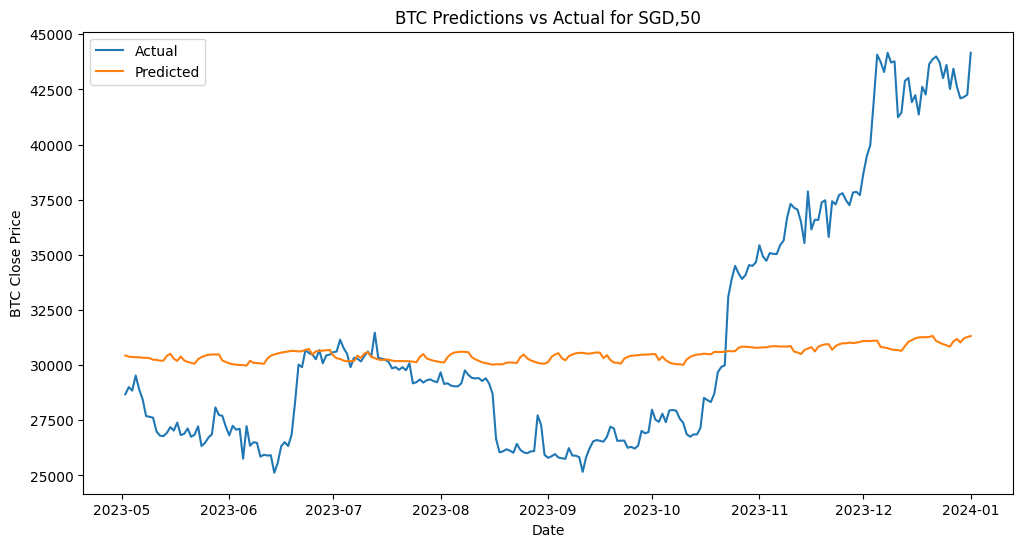

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.title("BTC Predictions vs Actual for SGD,50")
plt.legend()
plt.show()

## SGD,100

In [20]:
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader

# Fixed best parameters
hidden_size = 78
num_layers = 2
lr = 0.0007451964123638622
batch_size = 32
epochs = 100

# Model
input_size = btc_X_train_seq.shape[2]
model = BiLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=1
)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

# DataLoader
train_dataset = TensorDataset(
    torch.tensor(btc_X_train_seq, dtype=torch.float32),
    torch.tensor(btc_y_train_seq, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

# Training and recording loss
epoch_losses = []

model.train()
for epoch in range(epochs):
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs.squeeze(), yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    epoch_losses.append([epoch + 1, avg_loss])

# Save all 50 epoch losses into a dataframe
loss_df_100 = pd.DataFrame(epoch_losses, columns=["Epoch", "Loss"])

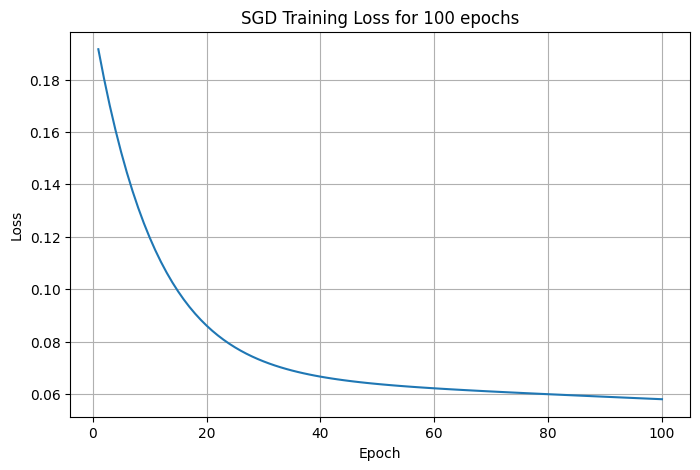

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_df_100["Epoch"], loss_df_100["Loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD Training Loss for 100 epochs")
plt.grid(True)
plt.show()